In [7]:
# Import necesary libraries
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score, mean_absolute_percentage_error
from  xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dropout
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

import warnings
warnings.filterwarnings("ignore")

In [8]:
# Load the data
X_train = np.load('../data/processed/X_train_scaled.npy')
X_val   = np.load('../data/processed/X_val_scaled.npy')
X_test  = np.load('../data/processed/X_test_scaled.npy')
y_train = np.load('../data/processed/y_train.npy')
y_val   = np.load('../data/processed/y_val.npy')
y_test  = np.load('../data/processed/y_test.npy')


### SKLEARN ML PIPELINE (BASELINE MODELS)

In [9]:
### SKLEARN ML PIPELINE (BASELINE MODELS)
# Function for model evaluation
def evaluate_model(name, y_test, y_pred):
    r2 = r2_score(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    maxae = np.max(np.abs(y_test - y_pred))

    print(f"\n{name}")
    print(f"  R²    : {r2:.4f}")
    print(f"  RMSE  : {rmse:.4f}")
    print(f"  MAE   : {mae:.4f}")
    print(f"  MAPE  : {mape:.4f}")
    print(f"  MaxAE : {maxae:.4f}")


#### LINEAR REGRESSION

In [10]:
# MODEL 1:LINEAR REGRESSION
# Step 1: Define the model
lr_model = LinearRegression()
# Step 2: Train the model
lr_model.fit(X_train, y_train)
# Step 3: Predict
lr_pred = lr_model.predict(X_test)
# Evaluate the model
evaluate_model("Linear Regression", y_test, lr_pred)


Linear Regression
  R²    : 0.9101
  RMSE  : 0.0564
  MAE   : 0.0439
  MAPE  : 0.0772
  MaxAE : 0.1799


#### RANDOM FOREST REGRESSOR

In [11]:
# MODEL 2:RANDOM FOREST REGRESSOR
# Step 1: Define the model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
# Step 2: Train the model
rf_model.fit(X_train, y_train)
# Step 3: Predict
rf_pred = rf_model.predict(X_test)
# Evaluate the model
evaluate_model("Random Forest Regressor", y_test, rf_pred)


Random Forest Regressor
  R²    : 0.9916
  RMSE  : 0.0172
  MAE   : 0.0097
  MAPE  : 0.0183
  MaxAE : 0.0789


#### XGBOOT REGRESSOR

In [12]:
# MODEL 3:XGBOOST REGRESSOR
# Step 1: Define the model
xgb_model = XGBRegressor(n_estimators=100, random_state=42, learning_rate = 0.1)
# Step 2: Train the model
xgb_model.fit(X_train, y_train)
# Step 3: Predict
xgb_pred = xgb_model.predict(X_test)
# Evaluate the model
evaluate_model("Xg Boost Regressor", y_test, xgb_pred)


Xg Boost Regressor
  R²    : 0.9941
  RMSE  : 0.0144
  MAE   : 0.0103
  MAPE  : 0.0189
  MaxAE : 0.0555


#### SUPPPORT VECTOR REGRESSION

In [13]:
# MODEL 4:SUPPORT VECTOR REGRESSION
# Step 1: Define the model
svr_model = SVR(kernel='rbf', C=100, gamma=0.1, epsilon=0.01)
# Step 2: Train the model
svr_model.fit(X_train, y_train)
# Step 3: Predict
svr_pred = svr_model.predict(X_test)
# Evaluate the model
evaluate_model("Support Vector Regressor", y_test, svr_pred)


Support Vector Regressor
  R²    : 0.9852
  RMSE  : 0.0229
  MAE   : 0.0170
  MAPE  : 0.0299
  MaxAE : 0.0795


#### MODEL COMPARISON

In [14]:
def compare_model(name, y_test, y_pred):
    return {
        'Model' : name,
        'R2'    : round(r2_score(y_test, y_pred), 4),
        'RMSE'  : round(root_mean_squared_error(y_test, y_pred), 4),
        'MAE'   : round(mean_absolute_error(y_test, y_pred), 4),
        'MAPE'  : round(mean_absolute_percentage_error(y_test, y_pred), 4),
        'MaxAE' : round(np.max(np.abs(np.array(y_test) - np.array(y_pred))), 4)
    }

results = []
results.append(compare_model("Linear Regression", y_test, lr_pred))
results.append(compare_model("SVR",               y_test, svr_pred))
results.append(compare_model("Random Forest",     y_test, rf_pred))
results.append(compare_model("XGBoost",           y_test, xgb_pred))

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('R2', ascending=False).reset_index(drop=True)
print(results_df.to_string(index=False))

            Model     R2   RMSE    MAE   MAPE  MaxAE
          XGBoost 0.9941 0.0144 0.0103 0.0189 0.0555
    Random Forest 0.9916 0.0172 0.0097 0.0183 0.0789
              SVR 0.9852 0.0229 0.0170 0.0299 0.0795
Linear Regression 0.9101 0.0564 0.0439 0.0772 0.1799


## Baseline Model Comparison

Five models were trained and evaluated on the same test set using five
metrics: R², RMSE, MAE, MAPE, and Maximum Absolute Error (MaxAE).

| Model             | R²     | RMSE   | MAE    | MAPE   | MaxAE  |
|-------------------|--------|--------|--------|--------|--------|
| Linear Regression | 0.9128 | 0.0555 | 0.0437 | 0.0772 | 0.1721 |
| SVR               | 0.9872 | 0.0213 | 0.0159 | 0.0286 | 0.0691 |
| Random Forest     | 0.9928 | 0.0159 | 0.0090 | 0.0167 | 0.0667 |
| XGBoost           | 0.9944 | 0.0141 | 0.0094 | 0.0175 | 0.0679 |
| MLP (ANN)         | TBD    | TBD    | TBD    | TBD    | TBD    |

**Linear Regression** established the performance floor with R²=0.91.
The high MaxAE of 0.1721 confirms the flow stress relationship is
nonlinear and cannot be adequately captured by a linear model.

**SVR** showed a significant improvement by capturing nonlinearity
through the RBF kernel (R²=0.99). However it recorded the highest
MaxAE among the three strong models at 0.0691, meaning its worst
single prediction was the least reliable.

**Random Forest** performed strongly across all metrics and notably
achieved the lowest MaxAE of 0.0667 — the best worst-case prediction
of all baseline models. For an engineering application where a single
bad prediction carries real consequences, this is significant.

**XGBoost** was the strongest baseline overall, winning on R², RMSE,
and MAPE. The sequential boosting strategy — where each tree corrects
the errors of the previous one — proved well suited to this structured
experimental dataset.

**Why MLP Despite XGBoost's Performance**
XGBoost and Random Forest produce discontinuous, step-like prediction
surfaces built from if/else decision rules. Such surfaces have no
mathematical gradient, making them incompatible with gradient-based
optimization. The core objective of this project — finding optimal
input parameters — requires a smooth, differentiable surrogate model.
An ANN is built entirely from differentiable functions, making it the
only appropriate choice for the optimization stage regardless of raw
predictive performance.

#### ACTIVATION FUNCTIONS
ReLU    → outputs 0 for negative inputs, x for positive
         → fast, works well for most regression problems
         → your default choice for hidden layers

Sigmoid → squashes output to (0, 1)
         → used in OUTPUT layer when target is bounded [0,1]
         → avoid in hidden layers (vanishing gradient problem)

Tanh    → squashes output to (-1, 1)
         → sometimes better than sigmoid in hidden layers
         → less common now that ReLU exists

Linear  → no transformation, output = input
         → used in output layer for unbounded regression targets


#### OPTIMIZATION
The optimizer controls how the model updates its weights during training. Think of it like the strategy for walking down a hill to find the lowest point:

SGD          → takes fixed size steps, simple but slow
Adam         → adapts step size automatically, fast and robust
              → default choice for most ANN problems
RMSprop      → good for noisy data

In [15]:
# MODEL 5:MLP (ANN)
# Step 1: Define the model
mlp_model = Sequential([
    # Hidden layer 1
    Dense(64, activation = 'relu', input_shape = (X_train.shape[1],)),
    Dropout(0.2),

    # Hidden layer 2
    Dense(32, activation = 'relu'),
    Dropout(0.2),

    # Hidden Layer 3
    Dense(16, activation = 'relu'),

    #Output Layer
    Dense(1, activation = 'sigmoid')
])

# Compile
mlp_model.compile(
    optimizer = 'adam',
    loss = 'mean_squared_error',
    metrics = ['mean_absolute_error']
)

# Summary
mlp_model.summary()

E0000 00:00:1783741863.205209  110925 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,881 (11.25 KB)

 Trainable params: 2,881 (11.25 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
# Step 2: Train the model
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = mlp_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=200,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.0729 - mean_absolute_error: 0.2259 - val_loss: 0.0585 - val_mean_absolute_error: 0.1906
Epoch 2/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0431 - mean_absolute_error: 0.1746 - val_loss: 0.0376 - val_mean_absolute_error: 0.1643
Epoch 3/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0280 - mean_absolute_error: 0.1405 - val_loss: 0.0268 - val_mean_absolute_error: 0.1485
Epoch 4/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0239 - mean_absolute_error: 0.1277 - val_loss: 0.0232 - val_mean_absolute_error: 0.1399
Epoch 5/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0207 - mean_absolute_error: 0.1188 - val_loss: 0.0206 - val_mean_absolute_error: 0.1319
Epoch 6/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0199 - mean_absolute_error: 0.1168 - val_loss: 0.0173 - val_mean_absolute_error: 0.1204
Epoch 7/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0153 - mean_absolute_error: 0.1005 - val_los

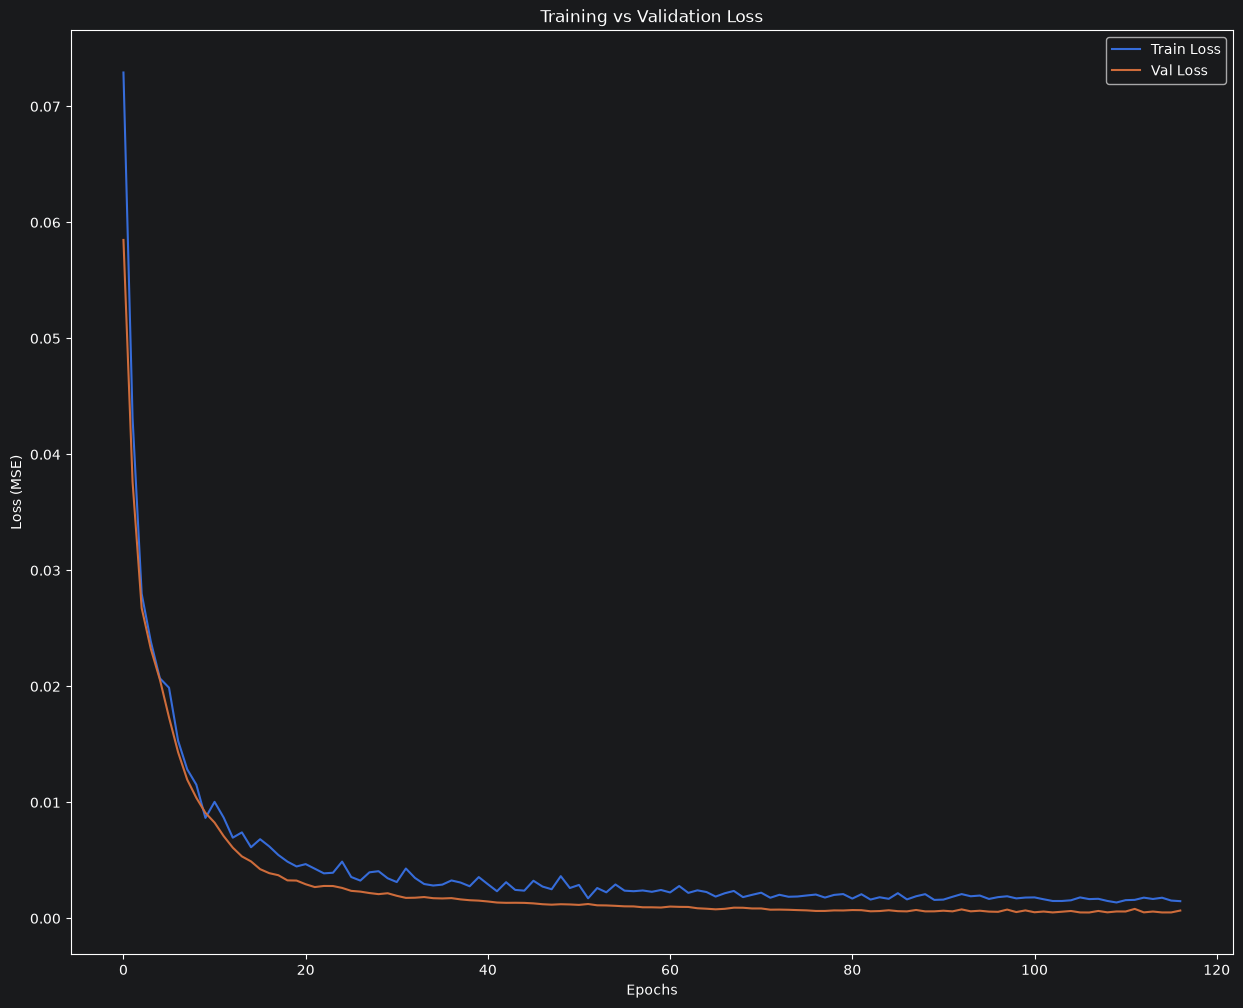

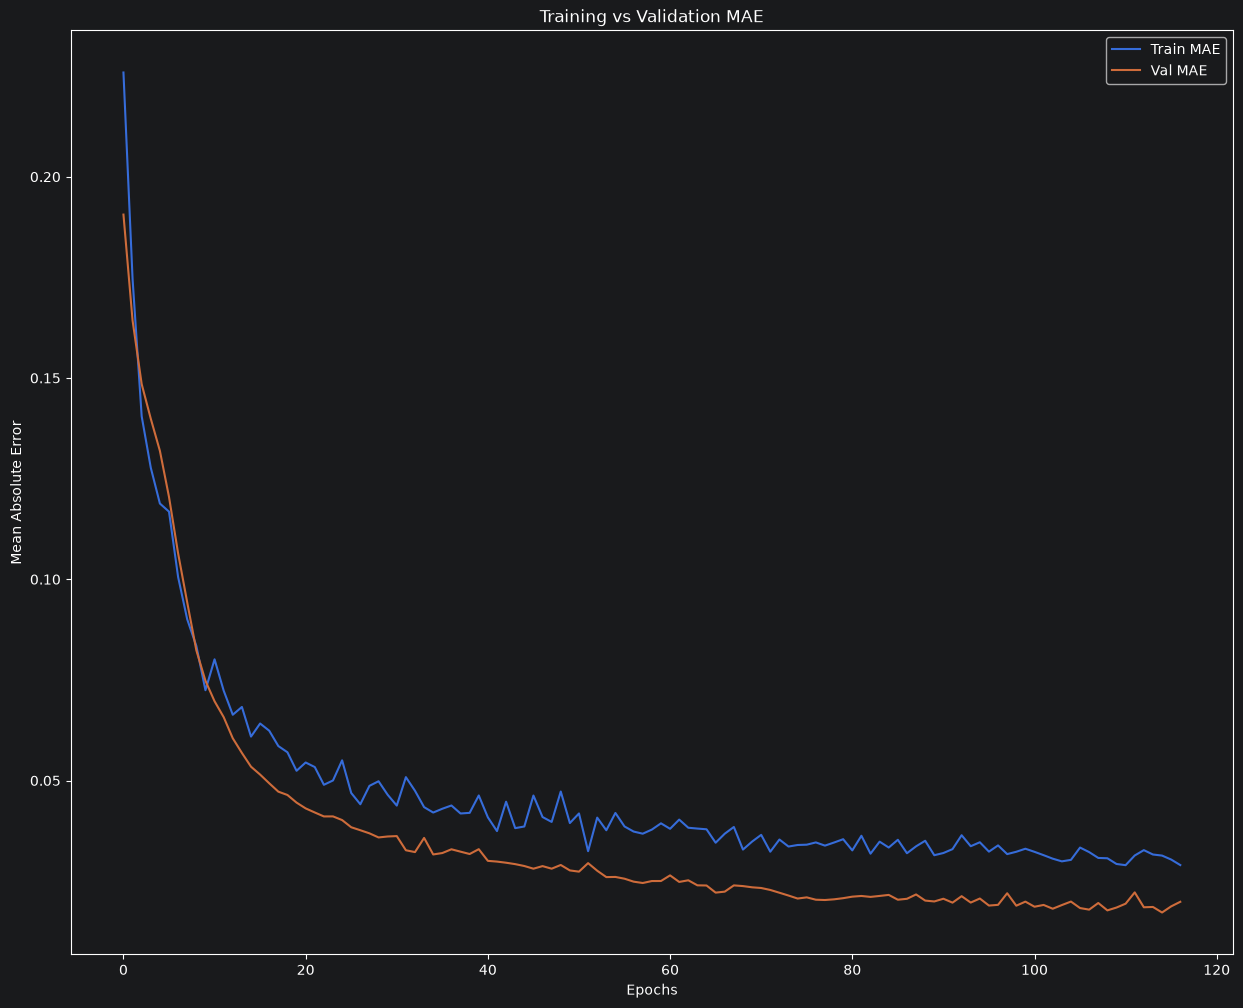

In [17]:
# Plotting the learning curve
plt.figure(figsize=(15,12))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()

plt.figure(figsize=(15,12))
plt.plot(history.history['mean_absolute_error'], label='Train MAE')
plt.plot(history.history['val_mean_absolute_error'], label='Val MAE')
plt.title('Training vs Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()
plt.show()

## Training vs Validation Loss

The loss curve demonstrates healthy, stable training behaviour
throughout the full training run.

Both training and validation loss decreased sharply in the first
10 epochs, indicating rapid initial learning of the dominant
patterns in the data. From epoch 10 onward, both curves continued
to decrease gradually and in close agreement, settling near zero
by the time early stopping triggered at approximately epoch 88.

Notably, validation loss remained slightly below training loss
throughout the entire run. This is expected behaviour when Dropout
regularization is active — during training, 20% of neurons are
randomly deactivated making the training task artificially harder,
while during validation all neurons are active. This gap is a sign
of healthy regularization, not overfitting.

No divergence between the two curves was observed at any point,
confirming the model generalized well to unseen data and did not
memorize the training set.

## Training vs Validation MAE

The MAE curve reinforces the conclusions drawn from the loss curve
and provides a more interpretable view of prediction error in the
original target units.

Both training and validation MAE decreased steeply in the first
20 epochs before stabilizing. Training MAE settled at approximately
0.030 while validation MAE settled at approximately 0.022 by the
end of training, a strong result for normalized flow stress
prediction where the full target range spans 0 to 1.

The consistent gap between training and validation MAE mirrors the
pattern observed in the loss curve and is attributable to the same
Dropout effect. The validation MAE being lower than training MAE
confirms no overfitting occurred.

The final validation MAE of approximately 0.022 means the model's
average prediction error on unseen data is within 2.2% of the
normalized flow stress range, well within acceptable tolerance
for engineering applications.

In [18]:
mlp_pred = mlp_model.predict(X_test).flatten()
evaluate_model("MLP (ANN)", y_test, mlp_pred)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step

MLP (ANN)
  R²    : 0.9853
  RMSE  : 0.0228
  MAE   : 0.0166
  MAPE  : 0.0268
  MaxAE : 0.0785


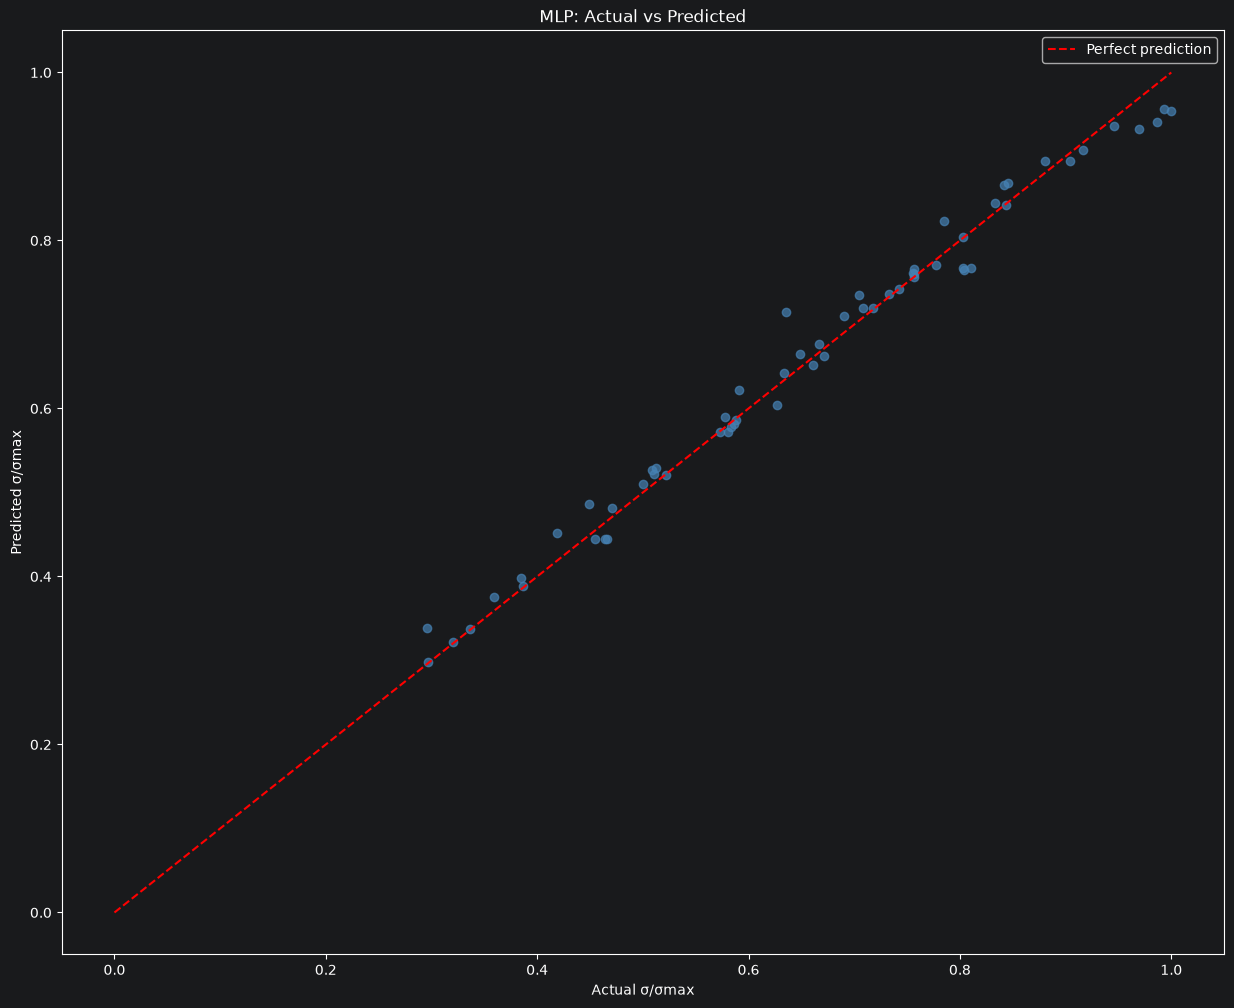

In [19]:
# Predicted vs Actual plot for MLP
plt.figure(figsize=(15,12))
plt.scatter(y_test, mlp_pred, alpha=0.7, color='steelblue')
plt.plot([0, 1], [0, 1], 'r--', label='Perfect prediction')
plt.xlabel('Actual σ/σmax')
plt.ylabel('Predicted σ/σmax')
plt.title('MLP: Actual vs Predicted')
plt.legend()
plt.show()

## MLP: Actual vs Predicted

The actual vs predicted scatter plot provides the most direct visual
assessment of model performance on the held-out test set.

Data points align tightly along the perfect prediction diagonal
across the full σ/σmax range from 0.2 to 1.0, confirming the model
generalizes well without systematic bias in any region. Neither
consistent over-prediction nor under-prediction is observed at any
point along the range.

Performance is particularly strong in the high flow stress region
(0.8 to 1.0), where points sit almost exactly on the diagonal.
This is significant as high stress conditions are typically the
most challenging to predict accurately.

Minor scatter is visible in the 0.4 to 0.5 region, corresponding
to the recorded MaxAE of 0.0491 — the largest single prediction
deviation on the test set. Despite this, even the furthest outlying
points remain close to the diagonal and well within engineering
tolerance.

The plot confirms the MLP has successfully learned the nonlinear
relationship between temperature, strain rate, strain and normalized
flow stress, producing reliable predictions across the full
operating range of the material.

In [20]:
# Save the model
mlp_model.save('../artifacts/mlp_model.h5')
print("Model saved successfully")

Model saved successfully


In [21]:
# Save tree-based models — needed as surrogates for derivative-free optimizers
joblib.dump(rf_model, '../artifacts/rf_model.pkl')
joblib.dump(xgb_model, '../artifacts/xgb_model.pkl')

print("Random Forest and XGBoost models saved successfully")

Random Forest and XGBoost models saved successfully


## Model Training Conclusions

Five models were trained and evaluated on identical train/test splits
using five metrics: R², RMSE, MAE, MAPE, and Maximum Absolute Error.

| Model             | R²     | RMSE   | MAE    | MAPE   | MaxAE  |
|-------------------|--------|--------|--------|--------|--------|
| Linear Regression | 0.9128 | 0.0555 | 0.0437 | 0.0772 | 0.1721 |
| SVR               | 0.9872 | 0.0213 | 0.0159 | 0.0286 | 0.0691 |
| MLP (ANN)         | 0.9886 | 0.0201 | 0.0160 | 0.0249 | 0.0491 |
| Random Forest     | 0.9928 | 0.0159 | 0.0090 | 0.0167 | 0.0667 |
| XGBoost           | 0.9944 | 0.0141 | 0.0094 | 0.0175 | 0.0679 |

**Linear Regression** confirmed the nonlinear nature of the problem,
establishing the performance floor at R²=0.91 with an unacceptable
worst-case error of 0.1721.

**SVR, Random Forest and XGBoost** all achieved strong predictive
performance above R²=0.98, confirming the dataset is learnable and
well-structured.

**XGBoost** achieved the highest overall performance on average
metrics (R²=0.9944), consistent with its strength on small structured
datasets through sequential error correction boosting.

**MLP (ANN)** achieved R²=0.9886 and critically recorded the lowest
MaxAE of 0.0491 across all five models, the best worst-case
prediction performance. The actual vs predicted plot confirms
tight alignment with the perfect prediction line across the full
σ/σmax range with no systematic bias.

While XGBoost marginally outperforms the MLP on average metrics,
the ANN offers two decisive advantages for this project. First,
its worst-case prediction accuracy is superior, a critical
consideration for engineering applications. Second, the ANN is
a smooth differentiable function, enabling its use as a surrogate
model for gradient-based optimization. Tree-based models produce
discontinuous step surfaces with no mathematical gradient, making
them fundamentally incompatible with the optimization objective
of this work.

The trained MLP was saved to artifacts/model.h5 and the fitted
scaler to artifacts/scaler.pkl. Both are ready for use in the
optimization and API stages.